(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000



Missing Values:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Duplicates: 0


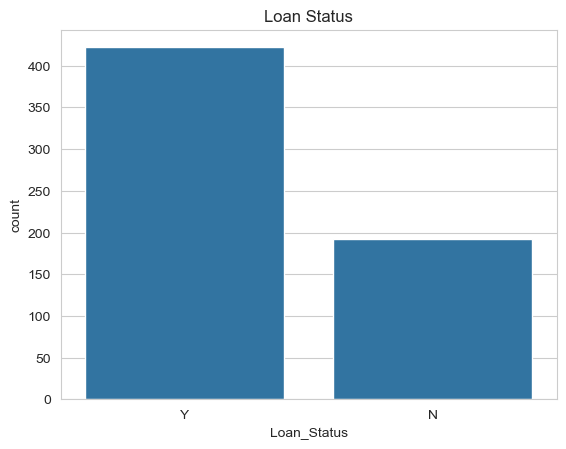

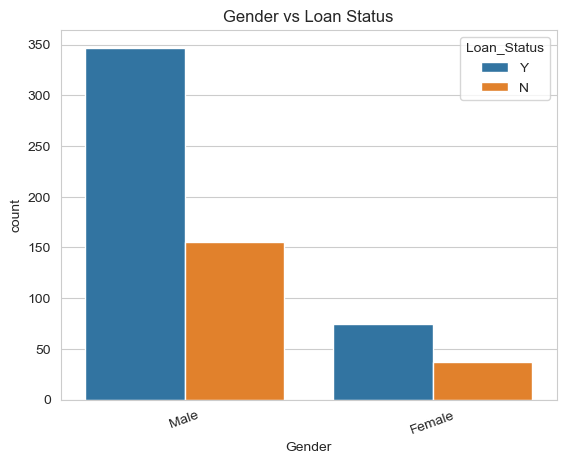

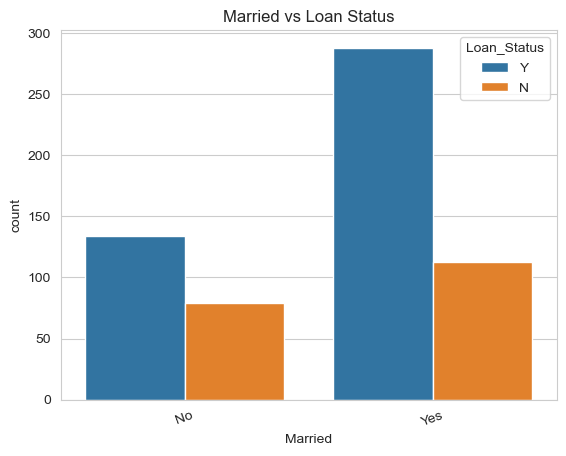

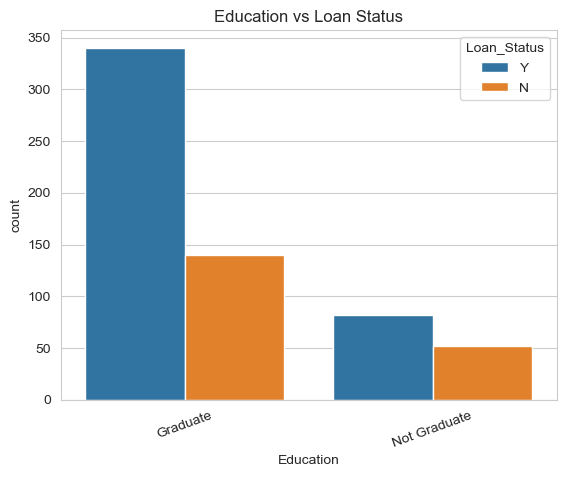

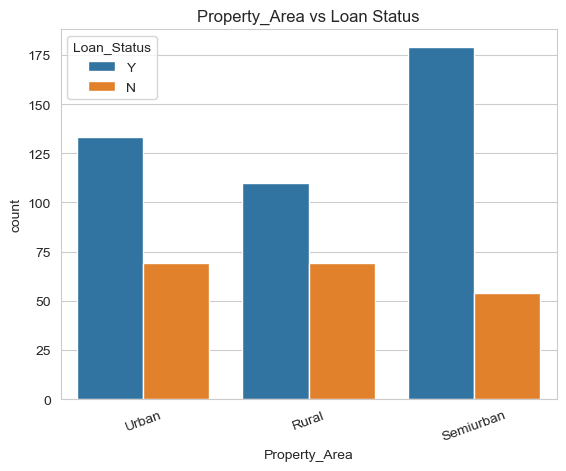

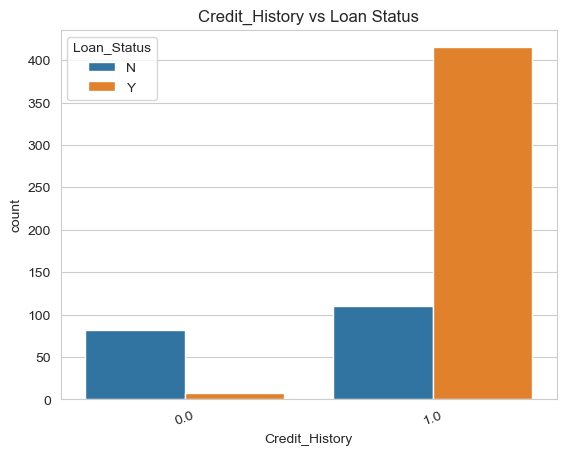

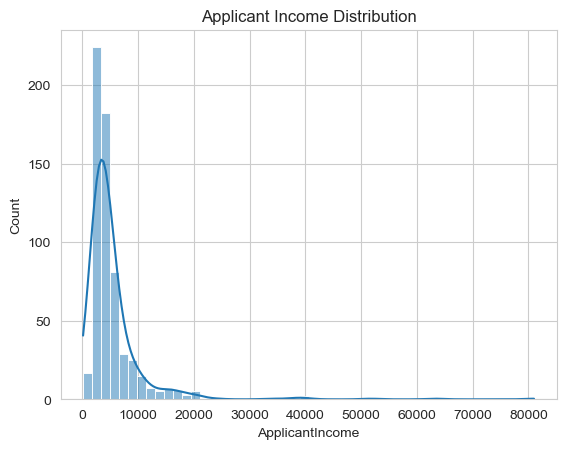

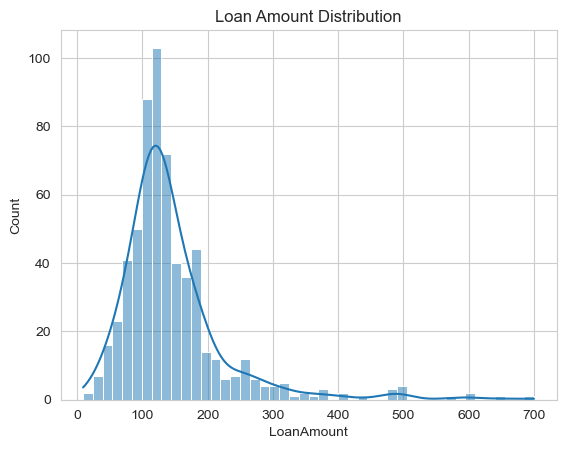

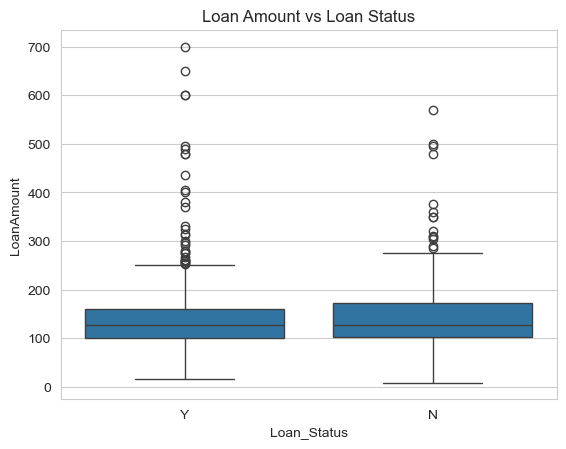

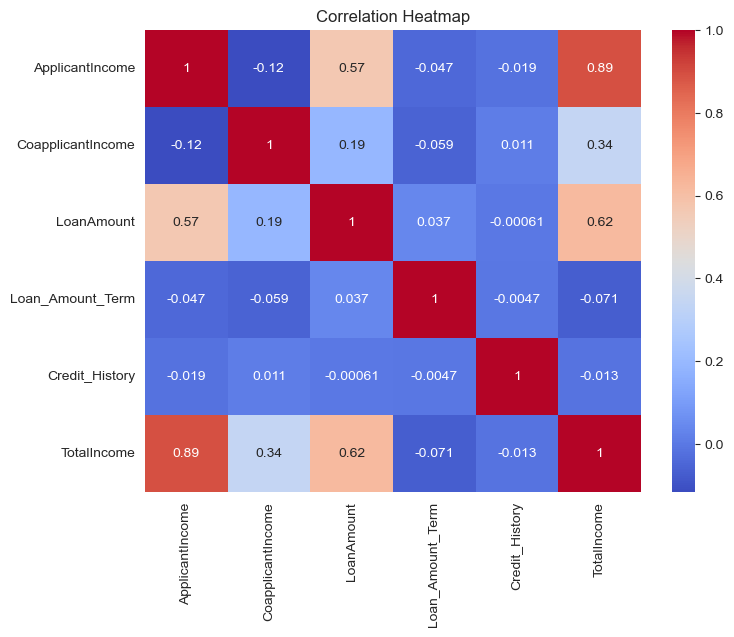


Final Shape: (614, 16)

Missing Values:
ApplicantIncome            0
CoapplicantIncome          0
LoanAmount                 0
Loan_Amount_Term           0
Credit_History             0
Loan_Status                0
TotalIncome                0
Gender_Male                0
Married_Yes                0
Dependents_1               0
Dependents_2               0
Dependents_3+              0
Education_Not Graduate     0
Self_Employed_Yes          0
Property_Area_Semiurban    0
Property_Area_Urban        0
dtype: int64


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,TotalIncome,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,5849.0,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,6091.0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,3000.0,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,4941.0,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,6000.0,True,False,False,False,False,False,False,False,True



EDA and Data Cleaning Completed!


In [3]:
# Loan Prediction - EDA + Data Cleaning

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Load data
df = pd.read_csv("first.csv")

# 1. Basic EDA
print(df.shape)
print(df.info())
display(df.head())
display(df.describe())

# 2. Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# 3. Duplicates
print("\nDuplicates:", df.duplicated().sum())

# 4. Data Cleaning
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed"]
num_cols = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# 5. Feature Engineering
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]

# 6. Target distribution
sns.countplot(data=df, x="Loan_Status")
plt.title("Loan Status")
plt.show()

# 7. Categorical visualization
cols = ["Gender", "Married", "Education", "Property_Area", "Credit_History"]

for col in cols:
    sns.countplot(data=df, x=col, hue="Loan_Status")
    plt.title(f"{col} vs Loan Status")
    plt.xticks(rotation=20)
    plt.show()

# 8. Numerical visualization
sns.histplot(df["ApplicantIncome"], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

sns.histplot(df["LoanAmount"], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

# 9. Boxplots
sns.boxplot(data=df, x="Loan_Status", y="LoanAmount")
plt.title("Loan Amount vs Loan Status")
plt.show()

# 10. Correlation
corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# 11. Encode categorical variables
df = df.drop("Loan_ID", axis=1)

df["Loan_Status"] = df["Loan_Status"].map({
    "N": 0,
    "Y": 1
})

df = pd.get_dummies(
    df,
    columns=["Gender", "Married", "Dependents",
             "Education", "Self_Employed", "Property_Area"],
    drop_first=True
)

# 12. Final check
print("\nFinal Shape:", df.shape)
print("\nMissing Values:")
print(df.isnull().sum())

display(df.head())

# Save cleaned data
df.to_csv("loan_prediction_cleaned.csv", index=False)

print("\nEDA and Data Cleaning Completed!")